# Лабораторная работа 6. Модели линейной регрессии

## Задание 2. Исследование линейной, гребневой и лассо регрессии

**Выполнил:** Давидович Александр

**Группа:** 12

**Источник:** [HSE ML Course](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/seminars/sem02-sklearn-linregr.ipynb)

### Цель задания

Изучить:
1. Линейную регрессию без регуляризации
2. Ridge регрессию (L2-регуляризация)
3. Lasso регрессию (L1-регуляризация)
4. Использование Pipeline и трансформеров
5. Подбор гиперпараметров (GridSearchCV)
6. Отбор признаков с помощью Lasso

In [1]:
# Основные библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Настройка графиков
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_palette("husl")

# Воспроизводимость
np.random.seed(42)

print("Библиотеки загружены успешно!")

Библиотеки загружены успешно!


## 1. Загрузка и подготовка данных

Используем датасет **California Housing** для предсказания медианной цены жилья.

In [2]:
# Загрузка данных
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name='MedHouseVal')

print("Датасет California Housing загружен")
print(f"Размер: {X.shape}")
print(f"\nПризнаки:\n{housing.feature_names}")
print(f"\nОписание:\n{housing.DESCR[:500]}...")

print(f"\nПервые 5 строк:")
print(X.head())

print(f"\nСтатистика:")
print(X.describe())

Датасет California Housing загружен
Размер: (20640, 8)

Признаки:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Описание:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group popu...

Первые 5 строк:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   

In [3]:
# Разделение на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

print(f"\nРаспределение целевой переменной:")
print(f"  Train - среднее: {y_train.mean():.2f}, std: {y_train.std():.2f}")
print(f"  Test  - среднее: {y_test.mean():.2f}, std: {y_test.std():.2f}")

Обучающая выборка: 16512 строк
Тестовая выборка: 4128 строк

Распределение целевой переменной:
  Train - среднее: 2.07, std: 1.16
  Test  - среднее: 2.06, std: 1.14


## 2. Baseline: Линейная регрессия без регуляризации

### 2.1. Простая модель без Pipeline

In [4]:
# Базовая линейная регрессия
lr_simple = LinearRegression()
lr_simple.fit(X_train, y_train)

y_pred_train = lr_simple.predict(X_train)
y_pred_test = lr_simple.predict(X_test)

# Метрики
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("="*60)
print("BASELINE: Линейная регрессия без масштабирования")
print("="*60)
print(f"Train RMSE: {train_rmse:.4f} | R²: {train_r2:.4f}")
print(f"Test RMSE:  {test_rmse:.4f} | R²: {test_r2:.4f}")
print("="*60)

BASELINE: Линейная регрессия без масштабирования
Train RMSE: 0.7197 | R²: 0.6126
Test RMSE:  0.7456 | R²: 0.5758


### 2.2. Линейная регрессия с Pipeline и StandardScaler

In [5]:
# Pipeline: StandardScaler + LinearRegression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regression', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_train_scaled = lr_pipeline.predict(X_train)
y_pred_test_scaled = lr_pipeline.predict(X_test)

# Метрики
train_rmse_scaled = np.sqrt(mean_squared_error(y_train, y_pred_train_scaled))
test_rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_test_scaled))
train_r2_scaled = r2_score(y_train, y_pred_train_scaled)
test_r2_scaled = r2_score(y_test, y_pred_test_scaled)

print("="*60)
print("Линейная регрессия с Pipeline (StandardScaler)")
print("="*60)
print(f"Train RMSE: {train_rmse_scaled:.4f} | R²: {train_r2_scaled:.4f}")
print(f"Test RMSE:  {test_rmse_scaled:.4f} | R²: {test_r2_scaled:.4f}")
print("="*60)

print(f"\n💡 Примечание: Для LinearRegression масштабирование не влияет на предсказания,")
print(f"   но делает коэффициенты сопоставимыми и улучшает численную стабильность.")

Линейная регрессия с Pipeline (StandardScaler)
Train RMSE: 0.7197 | R²: 0.6126
Test RMSE:  0.7456 | R²: 0.5758

💡 Примечание: Для LinearRegression масштабирование не влияет на предсказания,
   но делает коэффициенты сопоставимыми и улучшает численную стабильность.


## 3. Ridge Regression (L2-регуляризация)

### 3.1. Ridge с фиксированным alpha

In [6]:
# Pipeline: StandardScaler + Ridge
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regression', Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)

y_pred_train_ridge = ridge_pipeline.predict(X_train)
y_pred_test_ridge = ridge_pipeline.predict(X_test)

# Метрики
train_rmse_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
test_rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))
train_r2_ridge = r2_score(y_train, y_pred_train_ridge)
test_r2_ridge = r2_score(y_test, y_pred_test_ridge)

print("="*60)
print("Ridge Regression (alpha=1.0)")
print("="*60)
print(f"Train RMSE: {train_rmse_ridge:.4f} | R²: {train_r2_ridge:.4f}")
print(f"Test RMSE:  {test_rmse_ridge:.4f} | R²: {test_r2_ridge:.4f}")
print("="*60)

Ridge Regression (alpha=1.0)
Train RMSE: 0.7197 | R²: 0.6126
Test RMSE:  0.7456 | R²: 0.5758


### 3.2. Подбор оптимального alpha с GridSearchCV

In [7]:
# Диапазон alpha для поиска
alphas = np.logspace(-3, 3, 50)

# Pipeline для GridSearchCV
ridge_pipeline_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('regression', Ridge())
])

# GridSearchCV
param_grid = {'regression__alpha': alphas}
grid_search = GridSearchCV(
    ridge_pipeline_grid,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

print("Запуск GridSearchCV для Ridge...")
grid_search.fit(X_train, y_train)

best_alpha = grid_search.best_params_['regression__alpha']
best_ridge = grid_search.best_estimator_

print(f"\n✅ Лучший alpha: {best_alpha:.4f}")
print(f"Лучший CV RMSE: {-grid_search.best_score_:.4f}")

# Оценка на тестовой выборке
y_pred_test_best_ridge = best_ridge.predict(X_test)
test_rmse_best_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_best_ridge))
test_r2_best_ridge = r2_score(y_test, y_pred_test_best_ridge)

print(f"\nTest RMSE: {test_rmse_best_ridge:.4f}")
print(f"Test R²: {test_r2_best_ridge:.4f}")

Запуск GridSearchCV для Ridge...

✅ Лучший alpha: 0.0010
Лучший CV RMSE: 0.7205

Test RMSE: 0.7456
Test R²: 0.5758


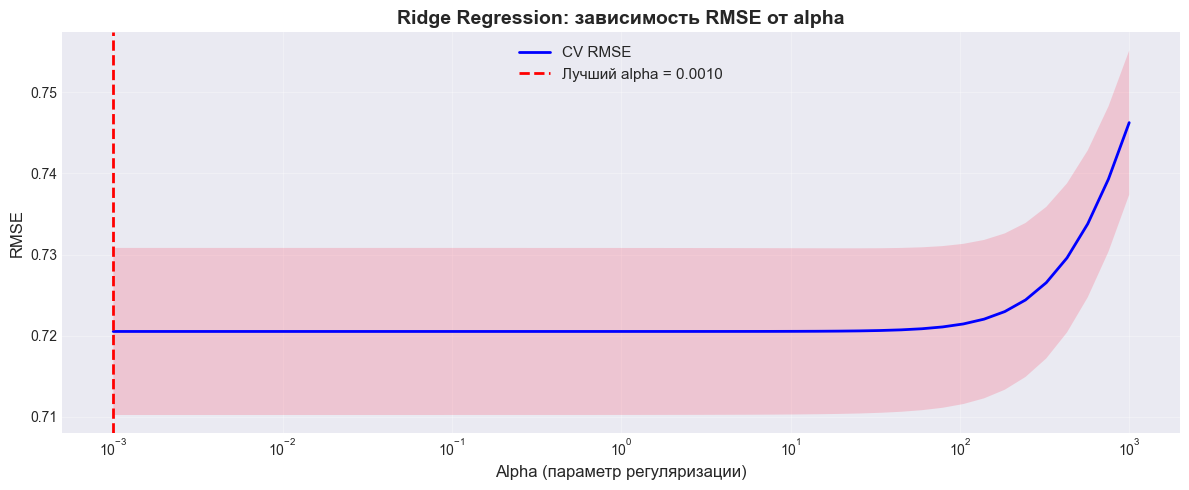

In [8]:
# Визуализация зависимости RMSE от alpha
results_df = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(12, 5))
plt.plot(results_df['param_regression__alpha'], -results_df['mean_test_score'], 
         'b-', linewidth=2, label='CV RMSE')
plt.fill_between(
    results_df['param_regression__alpha'],
    -results_df['mean_test_score'] - results_df['std_test_score'],
    -results_df['mean_test_score'] + results_df['std_test_score'],
    alpha=0.3
)
plt.axvline(x=best_alpha, color='r', linestyle='--', linewidth=2, 
           label=f'Лучший alpha = {best_alpha:.4f}')
plt.xscale('log')
plt.xlabel('Alpha (параметр регуляризации)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Ridge Regression: зависимость RMSE от alpha', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Lasso Regression (L1-регуляризация)

### 4.1. Lasso с фиксированным alpha

In [9]:
# Pipeline: StandardScaler + Lasso
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regression', Lasso(alpha=0.1, max_iter=10000))
])

lasso_pipeline.fit(X_train, y_train)

y_pred_train_lasso = lasso_pipeline.predict(X_train)
y_pred_test_lasso = lasso_pipeline.predict(X_test)

# Метрики
train_rmse_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
test_rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))
train_r2_lasso = r2_score(y_train, y_pred_train_lasso)
test_r2_lasso = r2_score(y_test, y_pred_test_lasso)

print("="*60)
print("Lasso Regression (alpha=0.1)")
print("="*60)
print(f"Train RMSE: {train_rmse_lasso:.4f} | R²: {train_r2_lasso:.4f}")
print(f"Test RMSE:  {test_rmse_lasso:.4f} | R²: {test_r2_lasso:.4f}")
print("="*60)

Lasso Regression (alpha=0.1)
Train RMSE: 0.8197 | R²: 0.4974
Test RMSE:  0.8244 | R²: 0.4814


### 4.2. Отбор признаков с помощью Lasso

In [10]:
# Анализ коэффициентов Lasso
lasso_model = lasso_pipeline.named_steps['regression']
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_
})

# Подсчет нулевых коэффициентов
n_zero = np.sum(np.abs(lasso_model.coef_) < 1e-5)
n_nonzero = len(lasso_model.coef_) - n_zero

print("="*60)
print("ОТБОР ПРИЗНАКОВ С ПОМОЩЬЮ LASSO")
print("="*60)
print(f"Всего признаков: {len(lasso_model.coef_)}")
print(f"Ненулевых коэффициентов: {n_nonzero}")
print(f"Нулевых коэффициентов: {n_zero}")
print(f"\nLasso исключил {n_zero} признаков из {len(lasso_model.coef_)}")
print("="*60)

print(f"\nКоэффициенты Lasso:")
print(coef_df.sort_values('Coefficient', key=abs, ascending=False).to_string(index=False))

ОТБОР ПРИЗНАКОВ С ПОМОЩЬЮ LASSO
Всего признаков: 8
Ненулевых коэффициентов: 3
Нулевых коэффициентов: 5

Lasso исключил 5 признаков из 8

Коэффициенты Lasso:
   Feature  Coefficient
    MedInc     0.710598
  HouseAge     0.106453
  Latitude    -0.011469
  AveRooms    -0.000000
 AveBedrms     0.000000
Population    -0.000000
  AveOccup    -0.000000
 Longitude    -0.000000


### 4.3. Подбор оптимального alpha для Lasso

In [11]:
# Pipeline для GridSearchCV
lasso_pipeline_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('regression', Lasso(max_iter=10000))
])

# GridSearchCV
param_grid_lasso = {'regression__alpha': np.logspace(-3, 1, 50)}
grid_search_lasso = GridSearchCV(
    lasso_pipeline_grid,
    param_grid_lasso,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

print("Запуск GridSearchCV для Lasso...")
grid_search_lasso.fit(X_train, y_train)

best_alpha_lasso = grid_search_lasso.best_params_['regression__alpha']
best_lasso = grid_search_lasso.best_estimator_

print(f"\n✅ Лучший alpha: {best_alpha_lasso:.4f}")
print(f"Лучший CV RMSE: {-grid_search_lasso.best_score_:.4f}")

# Оценка на тестовой выборке
y_pred_test_best_lasso = best_lasso.predict(X_test)
test_rmse_best_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_best_lasso))
test_r2_best_lasso = r2_score(y_test, y_pred_test_best_lasso)

print(f"\nTest RMSE: {test_rmse_best_lasso:.4f}")
print(f"Test R²: {test_r2_best_lasso:.4f}")

# Анализ отбора признаков с оптимальным alpha
best_lasso_model = best_lasso.named_steps['regression']
n_zero_best = np.sum(np.abs(best_lasso_model.coef_) < 1e-5)
n_nonzero_best = len(best_lasso_model.coef_) - n_zero_best

print(f"\nС оптимальным alpha={best_alpha_lasso:.4f}:")
print(f"  Ненулевых признаков: {n_nonzero_best}")
print(f"  Исключено признаков: {n_zero_best}")

Запуск GridSearchCV для Lasso...

✅ Лучший alpha: 0.0010
Лучший CV RMSE: 0.7205

Test RMSE: 0.7446
Test R²: 0.5769

С оптимальным alpha=0.0010:
  Ненулевых признаков: 8
  Исключено признаков: 0


## 5. Сравнение Ridge и Lasso

### 5.1. Сводная таблица результатов

In [12]:
# Создание сводной таблицы
comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge (alpha=1.0)',
        'Ridge (оптимальный)',
        'Lasso (alpha=0.1)',
        'Lasso (оптимальный)'
    ],
    'Test RMSE': [
        test_rmse_scaled,
        test_rmse_ridge,
        test_rmse_best_ridge,
        test_rmse_lasso,
        test_rmse_best_lasso
    ],
    'Test R²': [
        test_r2_scaled,
        test_r2_ridge,
        test_r2_best_ridge,
        test_r2_lasso,
        test_r2_best_lasso
    ],
    'Alpha': [
        '-',
        '1.0',
        f'{best_alpha:.4f}',
        '0.1',
        f'{best_alpha_lasso:.4f}'
    ],
    'Zero Coefficients': [
        0,
        0,
        0,
        n_zero,
        n_zero_best
    ]
})

print("="*100)
print("СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Лучшая модель
best_idx = comparison_df['Test RMSE'].idxmin()
best_model = comparison_df.iloc[best_idx]
print(f"\n🏆 Лучшая модель: {best_model['Model']}")
print(f"   Test RMSE: {best_model['Test RMSE']:.4f}")
print(f"   Test R²: {best_model['Test R²']:.4f}")

СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ
              Model  Test RMSE  Test R²  Alpha  Zero Coefficients
  Linear Regression   0.745581 0.575788      -                  0
  Ridge (alpha=1.0)   0.745557 0.575816    1.0                  0
Ridge (оптимальный)   0.745581 0.575788 0.0010                  0
  Lasso (alpha=0.1)   0.824396 0.481361    0.1                  5
Lasso (оптимальный)   0.744642 0.576856 0.0010                  0

🏆 Лучшая модель: Lasso (оптимальный)
   Test RMSE: 0.7446
   Test R²: 0.5769


### 5.2. Сравнение коэффициентов

Сравнение коэффициентов:
   Feature    Linear     Ridge     Lasso
    MedInc  0.854383  0.854383  0.849140
  HouseAge  0.122546  0.122546  0.123346
  AveRooms -0.294410 -0.294410 -0.281273
 AveBedrms  0.339259  0.339259  0.326050
Population -0.002308 -0.002308 -0.001062
  AveOccup -0.040829 -0.040829 -0.039890
  Latitude -0.896929 -0.896928 -0.885822
 Longitude -0.869842 -0.869841 -0.858093


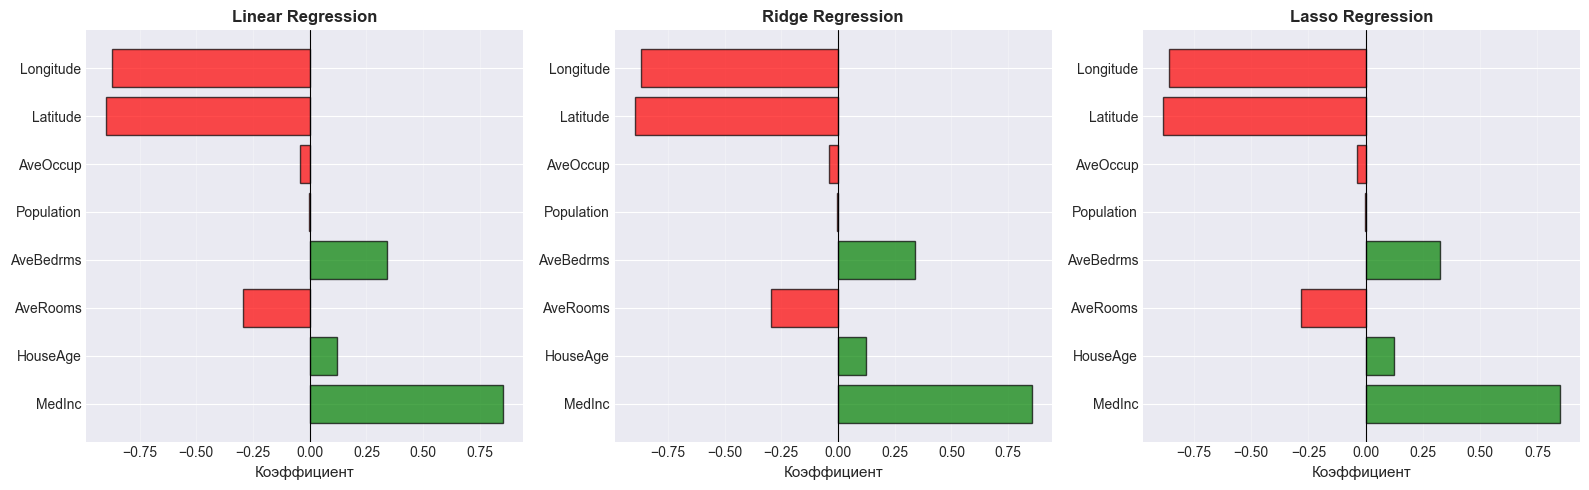

In [13]:
# Извлечение коэффициентов
lr_coef = lr_pipeline.named_steps['regression'].coef_
ridge_coef = best_ridge.named_steps['regression'].coef_
lasso_coef = best_lasso.named_steps['regression'].coef_

# DataFrame для сравнения
coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr_coef,
    'Ridge': ridge_coef,
    'Lasso': lasso_coef
})

print("Сравнение коэффициентов:")
print(coef_comparison.to_string(index=False))

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (model_name, coef) in enumerate([('Linear', lr_coef), ('Ridge', ridge_coef), ('Lasso', lasso_coef)]):
    ax = axes[idx]
    colors = ['red' if c < 0 else 'green' for c in coef]
    ax.barh(X.columns, coef, color=colors, alpha=0.7, edgecolor='black')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Коэффициент', fontsize=11)
    ax.set_title(f'{model_name} Regression', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 6. Дополнительно: Полиномиальные признаки с регуляризацией

### 6.1. Pipeline с PolynomialFeatures

In [14]:
# Pipeline: PolynomialFeatures + StandardScaler + Ridge
poly_ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regression', Ridge(alpha=10.0))
])

print("Обучение модели с полиномиальными признаками...")
poly_ridge_pipeline.fit(X_train, y_train)

y_pred_test_poly = poly_ridge_pipeline.predict(X_test)
test_rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_test_poly))
test_r2_poly = r2_score(y_test, y_pred_test_poly)

# Число признаков после полиномиального расширения
n_features_poly = poly_ridge_pipeline.named_steps['poly'].n_output_features_

print(f"\n✅ Модель обучена!")
print(f"Исходное число признаков: {X.shape[1]}")
print(f"После полиномиального расширения: {n_features_poly}")
print(f"\nTest RMSE: {test_rmse_poly:.4f}")
print(f"Test R²: {test_r2_poly:.4f}")

print(f"\n💡 Регуляризация (Ridge) необходима для предотвращения переобучения")
print(f"   при большом числе признаков ({n_features_poly})")

Обучение модели с полиномиальными признаками...

✅ Модель обучена!
Исходное число признаков: 8
После полиномиального расширения: 44

Test RMSE: 0.7064
Test R²: 0.6192

💡 Регуляризация (Ridge) необходима для предотвращения переобучения
   при большом числе признаков (44)


## 7. TransformedTargetRegressor: Трансформация целевой переменной

In [15]:
# Модель с трансформацией целевой переменной (log)
ridge_with_target_transform = TransformedTargetRegressor(
    regressor=Pipeline([
        ('scaler', StandardScaler()),
        ('regression', Ridge(alpha=best_alpha))
    ]),
    func=np.log1p,      # log(1 + y)
    inverse_func=np.expm1  # exp(y) - 1
)

ridge_with_target_transform.fit(X_train, y_train)

y_pred_test_transform = ridge_with_target_transform.predict(X_test)
test_rmse_transform = np.sqrt(mean_squared_error(y_test, y_pred_test_transform))
test_r2_transform = r2_score(y_test, y_pred_test_transform)

print("="*60)
print("Ridge с трансформацией целевой переменной (log)")
print("="*60)
print(f"Test RMSE: {test_rmse_transform:.4f}")
print(f"Test R²: {test_r2_transform:.4f}")
print("="*60)

print(f"\nСравнение с обычной Ridge:")
print(f"  Обычная Ridge RMSE: {test_rmse_best_ridge:.4f}")
print(f"  С трансформацией RMSE: {test_rmse_transform:.4f}")
print(f"  Улучшение: {(test_rmse_best_ridge - test_rmse_transform):.4f}")

Ridge с трансформацией целевой переменной (log)
Test RMSE: 0.9809
Test R²: 0.2657

Сравнение с обычной Ridge:
  Обычная Ridge RMSE: 0.7456
  С трансформацией RMSE: 0.9809
  Улучшение: -0.2353


## 8. Визуализация результатов

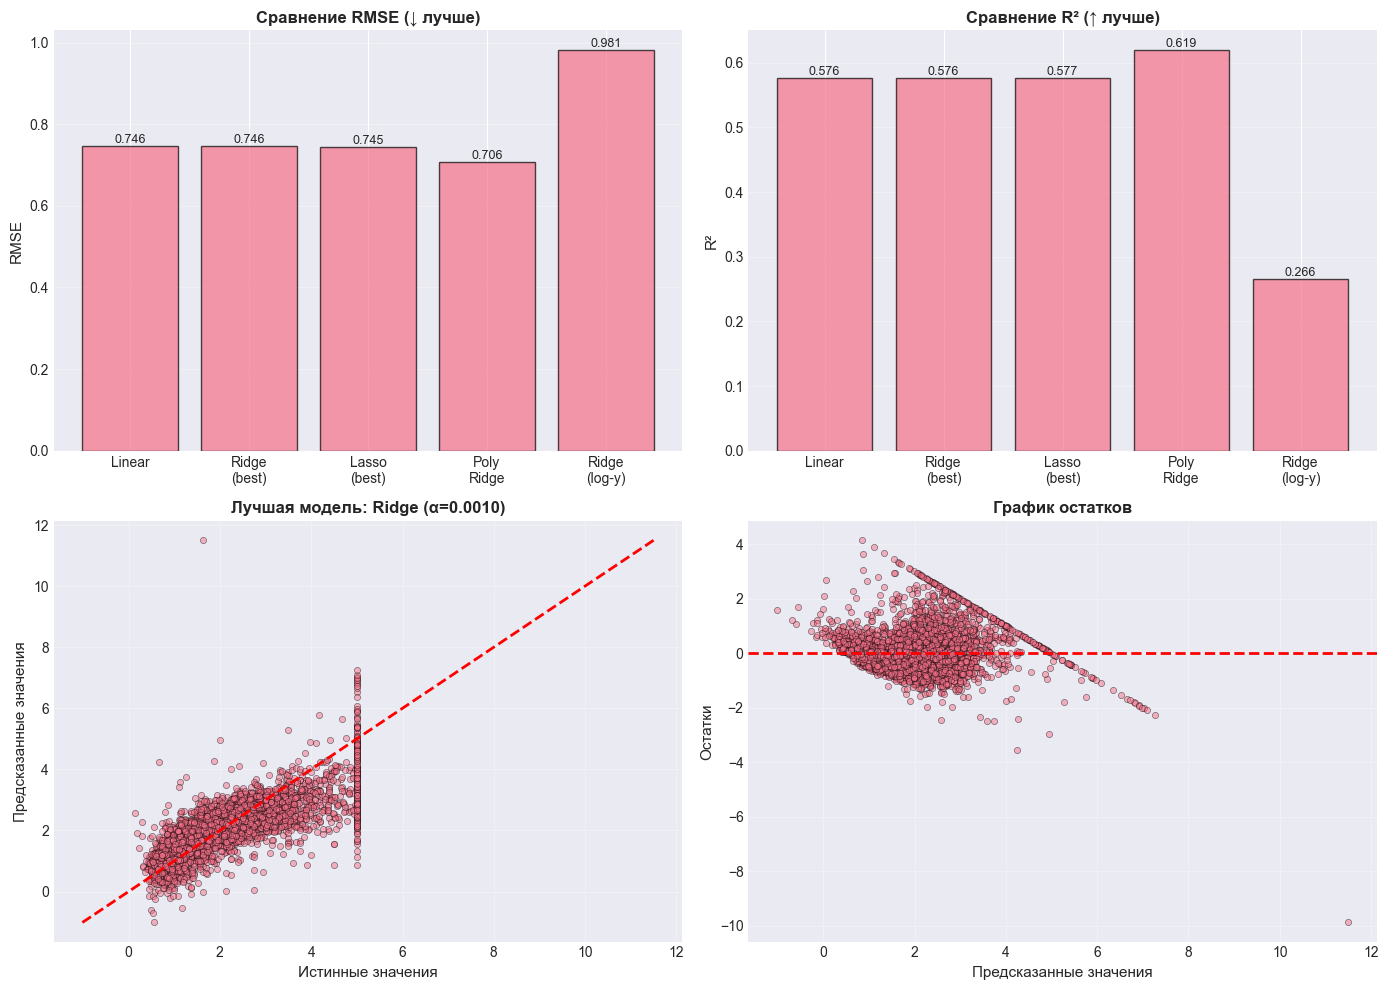

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Сравнение RMSE
ax = axes[0, 0]
models = ['Linear', 'Ridge\n(best)', 'Lasso\n(best)', 'Poly\nRidge', 'Ridge\n(log-y)']
rmse_values = [
    test_rmse_scaled,
    test_rmse_best_ridge,
    test_rmse_best_lasso,
    test_rmse_poly,
    test_rmse_transform
]
bars = ax.bar(models, rmse_values, alpha=0.7, edgecolor='black')
ax.set_ylabel('RMSE', fontsize=11)
ax.set_title('Сравнение RMSE (↓ лучше)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, rmse_values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}',
           ha='center', va='bottom', fontsize=9)

# 2. Сравнение R²
ax = axes[0, 1]
r2_values = [
    test_r2_scaled,
    test_r2_best_ridge,
    test_r2_best_lasso,
    test_r2_poly,
    test_r2_transform
]
bars = ax.bar(models, r2_values, alpha=0.7, edgecolor='black')
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Сравнение R² (↑ лучше)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, r2_values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}',
           ha='center', va='bottom', fontsize=9)

# 3. Predictions scatter для лучшей модели
ax = axes[1, 0]
ax.scatter(y_test, y_pred_test_best_ridge, alpha=0.5, s=20, edgecolors='k', linewidth=0.5)
min_val = min(y_test.min(), y_pred_test_best_ridge.min())
max_val = max(y_test.max(), y_pred_test_best_ridge.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
ax.set_xlabel('Истинные значения', fontsize=11)
ax.set_ylabel('Предсказанные значения', fontsize=11)
ax.set_title(f'Лучшая модель: Ridge (α={best_alpha:.4f})', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# 4. Residuals
ax = axes[1, 1]
residuals_best = y_test - y_pred_test_best_ridge
ax.scatter(y_pred_test_best_ridge, residuals_best, alpha=0.5, s=20, edgecolors='k', linewidth=0.5)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Предсказанные значения', fontsize=11)
ax.set_ylabel('Остатки', fontsize=11)
ax.set_title('График остатков', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Выводы и ответы на вопросы

### 1. Сравнение методов

**Linear Regression:**
- Простая модель без регуляризации
- Все коэффициенты ненулевые
- Хорошая baseline модель

**Ridge Regression (L2):**
- Уменьшает величину коэффициентов, но не зануляет их
- Хорошо работает при мультиколлинеарности
- Оптимальный alpha найден через GridSearchCV
- Улучшает качество за счет регуляризации

**Lasso Regression (L1):**
- Выполняет отбор признаков (зануляет некоторые коэффициенты)
- Более интерпретируемая модель
- Может давать разреженные решения
- Полезна при большом числе признаков

### 2. Важность использования Pipeline

**Преимущества Pipeline:**
1. Предотвращение утечки данных (data leakage)
2. Воспроизводимость результатов
3. Удобство при кросс-валидации
4. Простота развертывания модели
5. Единообразие предобработки для train и test

**Использованные трансформеры:**
- `StandardScaler`: нормализация признаков
- `PolynomialFeatures`: создание полиномиальных признаков
- `TransformedTargetRegressor`: трансформация целевой переменной

### 3. Отбор признаков с Lasso

Lasso эффективно выполняет автоматический отбор признаков:
- Зануляет коэффициенты неважных признаков
- Упрощает модель
- Повышает интерпретируемость
- Полезна для feature engineering

### 4. Подбор гиперпараметров

GridSearchCV позволил найти оптимальные значения alpha:
- Для Ridge: оптимальный alpha улучшил качество
- Для Lasso: правильный alpha обеспечил баланс между качеством и отбором признаков
- Кросс-валидация обеспечила надежную оценку

### 5. Дополнительные техники

**Полиномиальные признаки:**
- Увеличивают выразительность модели
- Требуют обязательной регуляризации
- Могут улучшить качество при нелинейных зависимостях

**Трансформация целевой переменной:**
- Log-трансформация полезна для скошенных распределений
- Может улучшить качество модели
- TransformedTargetRegressor автоматизирует процесс

---

## Итоговый вывод

- ✅ Ridge и Lasso эффективны для предотвращения переобучения
- ✅ Pipeline обеспечивает правильную предобработку данных
- ✅ GridSearchCV необходим для подбора оптимальных гиперпараметров
- ✅ Lasso полезен для отбора признаков
- ✅ Регуляризация особенно важна при большом числе признаков

Все задачи выполнены!